* [github salgo60/Svenskabadplatser](https://github.com/salgo60/Svenskabadplatser)
* this [Notebook](https://github.com/salgo60/Svenskabadplatser/blob/main/Jupyter/BathWater.ipynb)

* Looks like we dont get all data Sweden (SE) should have > 2500 reported bath waters see [issues/18](https://github.com/salgo60/Svenskabadplatser/issues/18)

In [1]:
from datetime import datetime
start_time  = datetime.now()
print("Last run: ", start_time)

Last run:  2021-05-13 22:59:03.640674


In [2]:
import requests
import pandas as pd

url = (
    "https://water.discomap.eea.europa.eu/arcgis/rest/services/"
    "BathingWater/BathingWater_Dyna_WM/MapServer/6/query"
)

params = {
    "where": "1=1",
    "outFields": "*",
    "f": "json"
}

response = requests.get(url, params=params)
response.raise_for_status()

features = response.json()["features"]

df = pd.json_normalize(
    [f["attributes"] for f in features]
)

print(df.shape)
df.head

(29, 10)


,OBJECTID,countryName,total,excellent,good,sufficient,poor,notClassified,nationalPortal,SHAPE_Area
0,1,Albania,119,80,28,3,8,0,https://akm.gov.al/,5.058671e+10
1,2,Austria,260,252,6,1,0,1,https://www.ages.at/themen/umwelt/wasser/badeg...,1.845098e+11
2,3,Belgium,128,98,26,3,0,1,https://www.eea.europa.eu/themes/water/europes...,7.613128e+10
3,4,Bulgaria,96,89,7,0,0,0,http://www.mh.government.bg/bg/administrativni...,2.061370e+11
4,5,Switzerland,196,153,13,2,6,22,https://www.bafu.admin.ch/bafu/en/home/state.html,8.852035e+10
5,6,Cyprus,120,119,0,0,0,1,http://www.moa.gov.cy/moa/environment/environm...,1.366326e+10
6,7,Czechia,156,120,20,3,0,13,https://www.mzcr.cz/category/ochrana-verejneho...,1.884222e+11
7,8,Germany,2292,2068,135,36,14,39,https://www.umweltbundesamt.de/wasserqualitaet...,9.072472e+11
8,9,Denmark,1039,980,42,6,3,8,http://mst.dk/natur-vand/vandmiljoe/badevand/,1.360623e+11
9,10,Estonia,65,42,16,3,1,3,http://vtiav.sm.ee/index.php/?active_tab_id=SV\r,1.694549e+11


In [3]:
#import pandas as pd
#import csv
#df = pd.read_csv('baths.csv', error_bad_lines=False,delimiter="|",warn_bad_lines=False)
#df.shape

In [7]:
dfg = df.sort_values("total", ascending=False)

In [8]:
import seaborn as sns
sns.set_theme()
sns.set(rc={'figure.figsize':(20,10)})
#dfg = df.groupby('countryCode').count()
#dfg = dfg.reset_index(inplace=False)

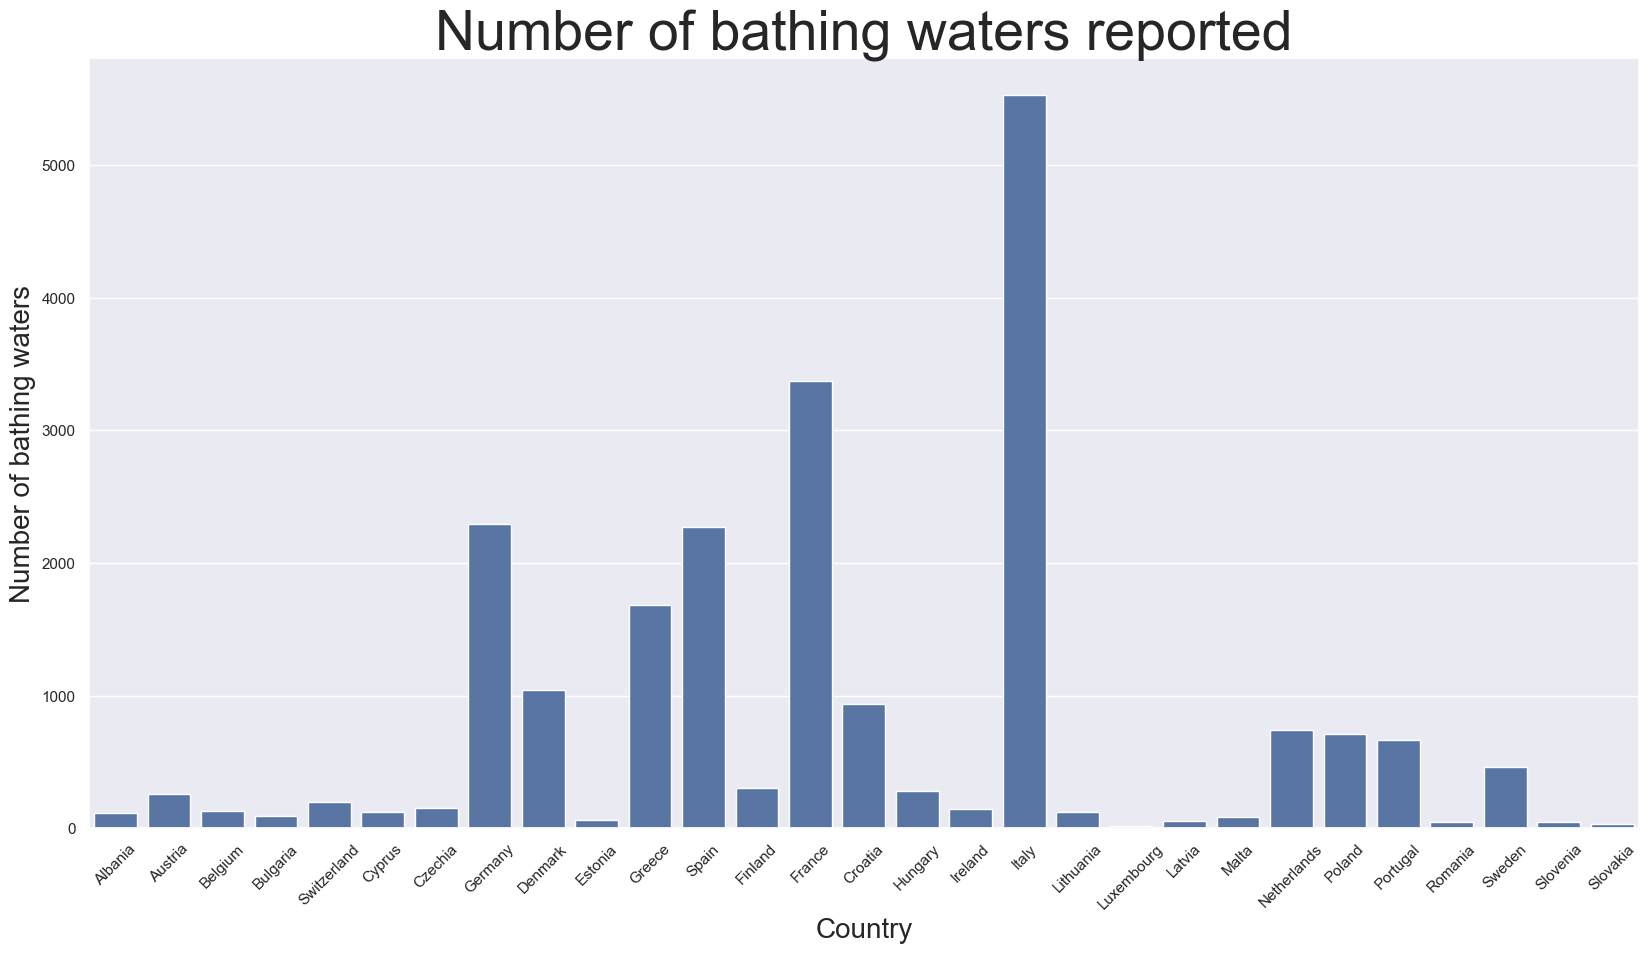

In [11]:
#p = sns.barplot(y=dfg.bathingWaterIdentifier,x=dfg.index, data=dfg)
#p.axes.set_title('Number unique bathingWaterIdentifiers reported',fontsize=40)
#p.set_xlabel("Country",fontsize=20)
#p.set_xticklabels(dfg['countryCode'], ha="center")
#p.set_ylabel("Number unique",fontsize=20)  
p = sns.barplot(
    data=df,
    x="countryName",
    y="total"
)

p.set_title("Number of bathing waters reported", fontsize=40)
p.set_xlabel("Country", fontsize=20)
p.set_ylabel("Number of bathing waters", fontsize=20)

p.tick_params(axis='x', rotation=45)

In [12]:
#dfgBW = dfg.sort_values(by=['bathingWaterIdentifier'])

In [13]:
#dfgBW

In [15]:
import requests
import pandas as p  
url = (
    "https://water.discomap.eea.europa.eu/arcgis/rest/services/"
    "BathingWater/BathingWater_Dyna_WM/MapServer/6/query"
)

params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": False,
    "f": "json"
}

r = requests.get(url, params=params)
r.raise_for_status()

features = r.json()["features"]

eea = pd.json_normalize(
    [f["attributes"] for f in features]
)

print(len(eea))
eea.head()

29


,OBJECTID,countryName,total,excellent,good,sufficient,poor,notClassified,nationalPortal,SHAPE_Area
0,1,Albania,119,80,28,3,8,0,https://akm.gov.al/,5.058671e+10
1,2,Austria,260,252,6,1,0,1,https://www.ages.at/themen/umwelt/wasser/badeg...,1.845098e+11
2,3,Belgium,128,98,26,3,0,1,https://www.eea.europa.eu/themes/water/europes...,7.613128e+10
3,4,Bulgaria,96,89,7,0,0,0,http://www.mh.government.bg/bg/administrativni...,2.061370e+11
4,5,Switzerland,196,153,13,2,6,22,https://www.bafu.admin.ch/bafu/en/home/state.html,8.852035e+10


In [16]:
query = """
SELECT ?item ?id WHERE {
  ?item wdt:P9616 ?id .
}
"""

url = "https://query.wikidata.org/sparql"

r = requests.get(
    url,
    params={"query": query, "format": "json"},
    headers={"User-Agent": "BathWaterNotebook/1.0"}
)

data = r.json()["results"]["bindings"]

wd = pd.DataFrame([
    {
        "item": row["item"]["value"],
        "id": row["id"]["value"]
    }
    for row in data
])

print(len(wd))
wd.head()

1350


,item,id
0,http://www.wikidata.org/entity/Q107122864,BG3411551500002008
1,http://www.wikidata.org/entity/Q107111654,NLBW59_5QMP01
2,http://www.wikidata.org/entity/Q107099487,CZKO811401
3,http://www.wikidata.org/entity/Q127685514,FRY1097701M971345
4,http://www.wikidata.org/entity/Q106706960,SE0A21482000000085


In [17]:
merged = eea.merge(
    wd,
    left_on="bathingWaterIdentifier",
    right_on="id",
    how="left"
)

missing = merged[merged["item"].isna()]

print(f"Saknas i Wikidata: {len(missing)}")

missing.head()

KeyError: 'bathingWaterIdentifier'